# Analyse av apple
Her laster vi inn data fra csv-fil, lager en enkel strategi som baserer seg på å kjøpe når prisen er under 30-dagers gjennomsnitt, og viser grafisk hvordan dette ser ut

In [79]:
import pandas as pd


file_path = "data/Apple Stock Price History.csv"
df = pd.read_csv(file_path)

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,09/01/2026,325.13,316.98,327.22,314.76,50.84M,2.61%
1,08/31/2026,316.85,319.60,321.23,312.80,41.24M,-0.89%
2,08/28/2026,319.70,316.85,322.37,315.45,38.65M,1.63%
3,08/27/2026,314.58,310.55,315.40,309.40,32.42M,0.36%
4,08/26/2026,313.45,310.30,315.43,308.80,34.02M,1.15%


In [80]:
# Clean and prepare the data
for col in ["Price", "Open", "High", "Low"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-01-02,271.01,272.26,277.84,269.00,37.84M,-0.31%
1,2026-01-05,267.26,270.64,271.51,266.14,45.65M,-1.38%
2,2026-01-06,262.36,267.00,267.55,262.12,52.35M,-1.83%
3,2026-01-07,260.33,263.20,263.68,259.81,48.31M,-0.77%
4,2026-01-08,259.04,257.02,259.29,255.70,50.42M,-0.50%


In [81]:
# Add the 30-day moving average
window = 30
df["MA_30"] = df["Price"].rolling(window=window, min_periods=1).mean()

df[["Date", "Price", "MA_30"]].tail()

,Date,Price,MA_30
162,2026-08-26,313.45,317.412000
163,2026-08-27,314.58,316.789333
164,2026-08-28,319.70,316.321333
165,2026-08-31,316.85,315.996667
166,2026-09-01,325.13,315.909667


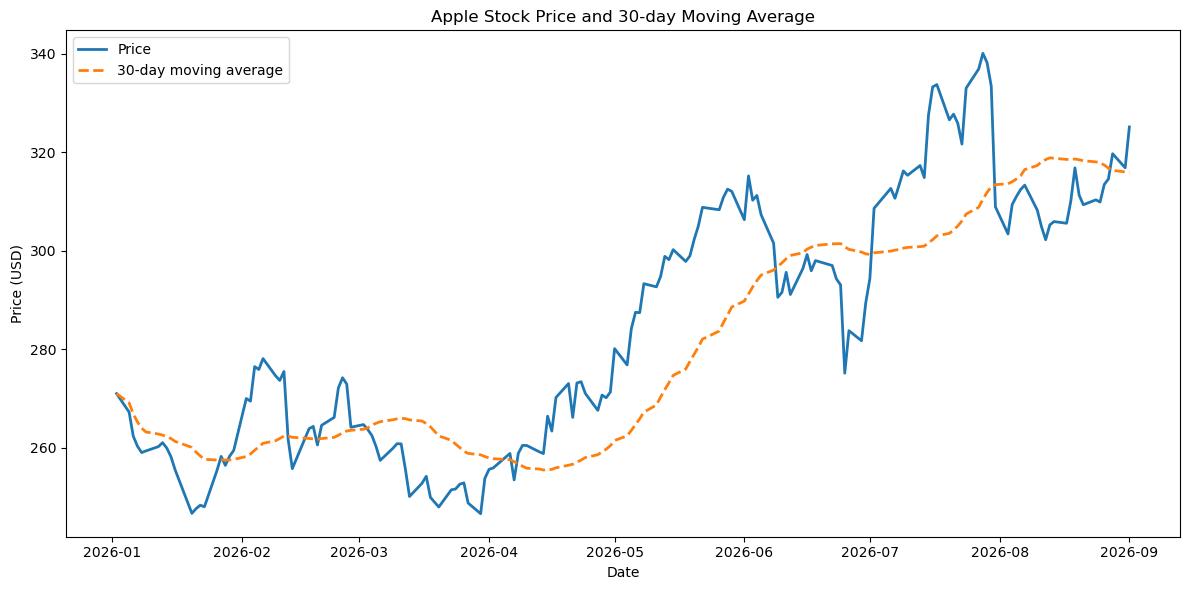

In [82]:
import matplotlib.pyplot as plt

# Plot price and moving average
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Price"], label="Price", linewidth=2)
plt.plot(df["Date"], df["MA_30"], label="30-day moving average", linewidth=2, linestyle="--")
plt.title("Apple Stock Price and 30-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# Create a binary indicator: 1 if price is below MA, otherwise 0
df["Buy_signal"] = (df["Price"] < df["MA_30"]).astype(int)

df[["Date", "Price", "MA_30", "Buy_signal"]].head()

,Date,Price,MA_30,Buy_signal
0,2026-01-02,271.01,271.010000,0
1,2026-01-05,267.26,269.135000,1
2,2026-01-06,262.36,266.876667,1
3,2026-01-07,260.33,265.240000,1
4,2026-01-08,259.04,264.000000,1


In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Backtest setup
initial_budget = 100_000
cash = initial_budget
shares = 0.0

cash_history = []
shares_history = []
portfolio_value_history = []

for _, row in df.iterrows():
    price = row["Price"]
    signal = row["Buy_signal"]

    if signal == 1:
        if cash > 0:
            shares = cash / price
            cash = 0.0
    elif signal == 0:
        if shares > 0:
            cash = shares * price
            shares = 0.0

    cash_history.append(cash)
    shares_history.append(shares)
    portfolio_value_history.append(cash + shares * price)

# Add results to the dataframe
df["Cash"] = cash_history
df["Shares"] = shares_history
df["Portfolio_Value"] = portfolio_value_history

final_value = df["Portfolio_Value"].iloc[-1]
profit_loss = final_value - initial_budget

print(f"Initial budget: {initial_budget:,.0f}")
print(f"Final portfolio value: {final_value:,.0f}")
print(f"Profit/Loss: {profit_loss:,.0f}")

df[["Date", "Price", "Buy_signal", "Cash", "Shares", "Portfolio_Value"]].head()

Initial budget: 100,000
Final portfolio value: 109,791
Profit/Loss: 9,791


,Date,Price,Buy_signal,Cash,Shares,Portfolio_Value
0,2026-01-02,271.01,0,100000.0,0.000000,100000.000000
1,2026-01-05,267.26,1,0.0,374.167477,100000.000000
2,2026-01-06,262.36,1,0.0,374.167477,98166.579361
3,2026-01-07,260.33,1,0.0,374.167477,97407.019382
4,2026-01-08,259.04,1,0.0,374.167477,96924.343336


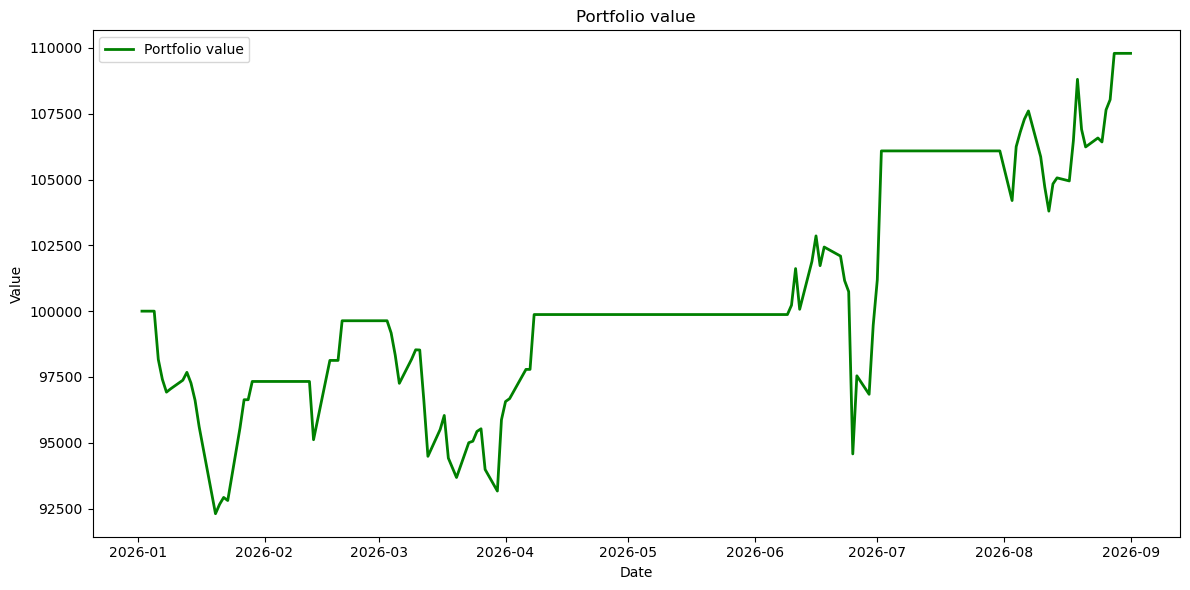

In [85]:
# Plot portfolio value against stock price scaled to start at the initial budget
start_price = df["Price"].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio value", linewidth=2, color="green")
plt.title("Portfolio value")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## Backtest result
This strategy invests the full available cash into shares whenever the buy signal is 1, and converts the position back to cash whenever the signal is 0.


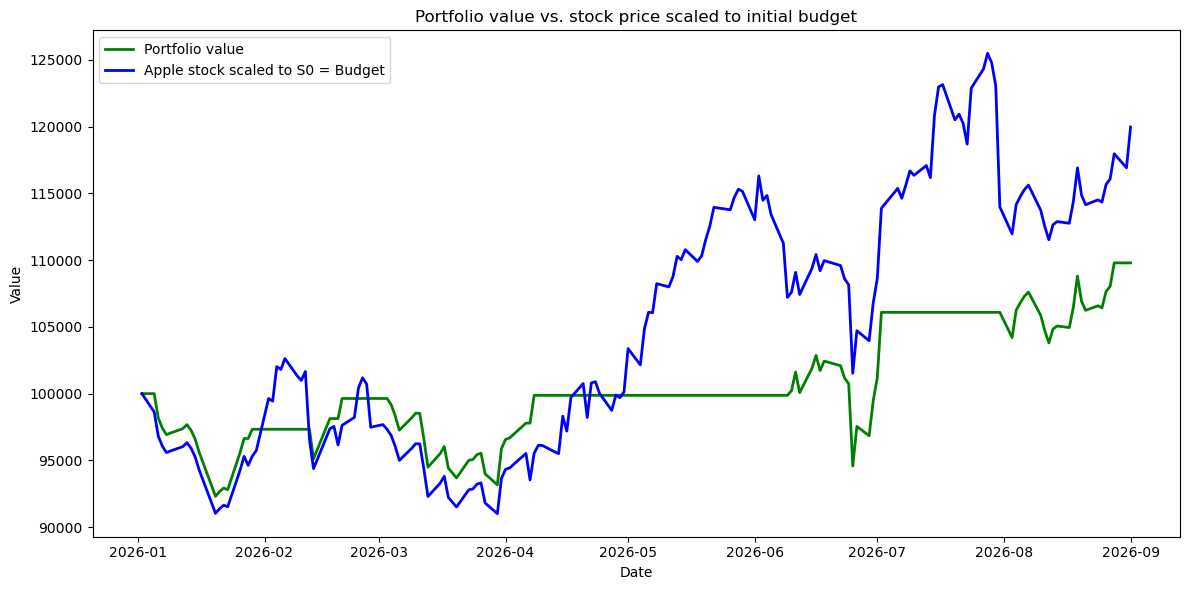

In [86]:
# Plot portfolio value against stock price scaled to start at the initial budget
start_price = df["Price"].iloc[0]
scaled_stock = (df["Price"] / start_price) * initial_budget

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Portfolio_Value"], label="Portfolio value", linewidth=2, color="green")
plt.plot(df["Date"], scaled_stock, label="Apple stock scaled to S0 = Budget", linewidth=2, color="blue")
plt.title("Portfolio value vs. stock price scaled to initial budget")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
df[["Date", "Price", "Buy_signal", "Cash", "Shares", "Portfolio_Value"]].tail()

,Date,Price,Buy_signal,Cash,Shares,Portfolio_Value
162,2026-08-26,313.45,1,0.000000,343.420145,107645.044512
163,2026-08-27,314.58,1,0.000000,343.420145,108033.109276
164,2026-08-28,319.70,0,109791.420419,0.000000,109791.420419
165,2026-08-31,316.85,0,109791.420419,0.000000,109791.420419
166,2026-09-01,325.13,0,109791.420419,0.000000,109791.420419


In [ ]:
print(f"Final scaled stock value: {scaled_stock.iloc[-1]:,.0f}")

KeyError: -1